<a href="https://colab.research.google.com/github/Atik1219/CaSRA-Supplier-Disruption-Prediction-Dataset/blob/main/Shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Suppier_Disruption_LogTable_Coded.csv to Suppier_Disruption_LogTable_Coded (2).csv


In [ ]:
import pandas as pd

df = pd.read_csv("Suppier_Disruption_LogTable_Coded.csv")
df.head()

,date,supplier,kg_score,Em_Score,twitter_alert,weather_risk,economic_risk,geo_risk,tech_risk,downtime_hours,high_disruption_p
0,1/1/2025,JHH,0.442711,0.552985,1,0,1,0,0,5.1,0.866602
1,1/2/2025,JHH,0.599101,0.509835,0,1,0,0,0,7.2,0.847657
2,1/3/2025,JHH,0.372080,0.532829,0,0,0,0,0,1.0,0.746924
3,1/4/2025,JHH,1.167822,0.571556,0,0,0,0,0,1.8,0.960245
4,1/5/2025,JHH,0.071730,0.591891,1,1,0,0,0,7.7,0.752698


In [ ]:
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.6).astype(int)

X = df[[
    "kg_score",
    "Em_Score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",

]]

y = df["high_disruption_label"]

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=65,
    eval_metric="logloss"
)

model.fit(X, y)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print("SHAP values computed.")

SHAP values computed.


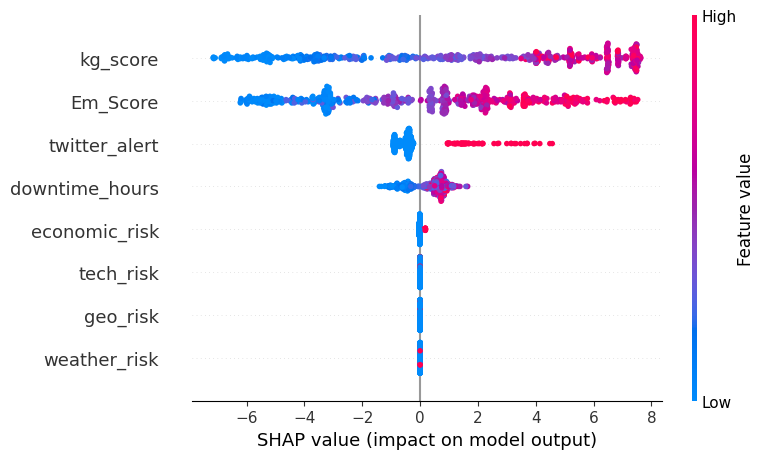

In [ ]:
shap.summary_plot(shap_values, X)

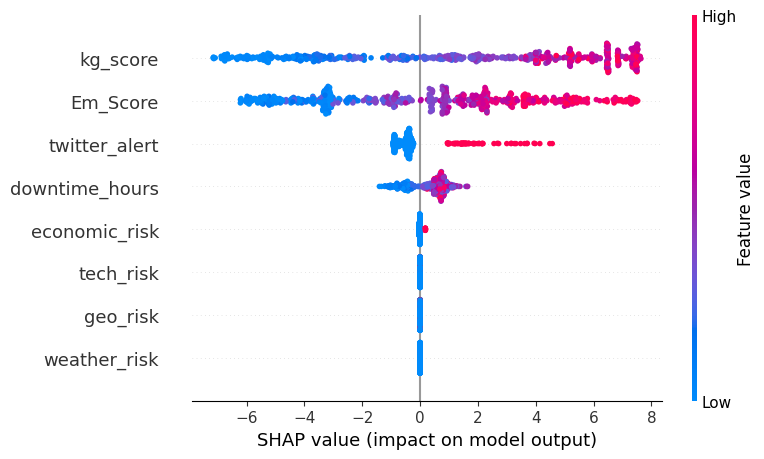

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")

In [ ]:
files.download("shap_summary_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>